# Ejercicio Ridge, Lasso y ElasticNet
Para este ejercicio vas a trabajar con datos de ventas de una empresa que fabrica muebles en España. Esta empresa es una Pyme que demanda conocer de antemano qué ingresos va a tener cada mes, ya que necesita pedir un anticipio a su entidad financiera de cara a poder abastecerse de materia prima al comenzar el mes. Como desconoce cuánto tiene que pedir, tira al alza y acaba pagando muchos intereses. El objetivo es reducir estos gastos.

En las bases de datos de la empresa constan todos los gastos en publicidad y ventas, para cada uno de los meses desde su fundación (hace más de 15 años).

Dado que los presupuestos de marketing se cierran al principio de cada mes, la empresa necesita un modelo predictivo que le anticipe las ventas que conseguirá a final de mes en función de los gastos que realizará en marketing.

Para ello tendrás que utilizar tanto modelos de regresión normales, como regularizados.

1. Carga los datos y realiza un pequeño análisis exploratorio. Mira a ver cómo se relaciona las ventas con el resto de variables.
2. Crea varios modelos y modifica los hiperparámetros necesarios para mejorar el performance del modelo.
3. Interpreta los resultados. Traduce a una fórmula tu mejor modelo (escribir la fórmula simplemente). ¿Cuánto cambian las ventas si aumentamos la inversión en radio un punto más? ¿Y si aumentamos la inversión en TV o periódicos?

## Import libraries 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Exploratory Data Analysis 

In [ ]:
# Lectura datos, relación variables, mapas de correlación...

In [ ]:
# Utiliza todas las celdas que necesites...

In [4]:
df = pd.read_csv('data/Advertising.csv', index_col=0)
df

,TV,radio,newpaper,sales
0,230.1,37.8,6s9.2,22100.0
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0
...,...,...,...,...
195,38.2,3.7,13.8,7600.0
196,94.2,4.9,8.1,9700.0
197,177.0,9.3,6.4,12800.0
198,283.6,42.0,66.2,25500.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   TV        200 non-null    float64
 1   radio     200 non-null    float64
 2   newpaper  200 non-null    object 
 3   sales     200 non-null    float64
dtypes: float64(3), object(1)
memory usage: 7.8+ KB


In [6]:
df.rename(columns={"newpaper": "newspaper"}, inplace=True)

In [9]:
df['newspaper'] = df['newspaper'].str.replace("s",'')
df['newspaper'] = df['newspaper'].astype(float)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


In [12]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14022.500000
std,85.854236,14.846809,21.778621,5217.456566
min,0.700000,0.000000,0.300000,1600.000000
25%,74.375000,9.975000,12.750000,10375.000000
50%,149.750000,22.900000,25.750000,12900.000000
75%,218.825000,36.525000,45.100000,17400.000000
max,296.400000,49.600000,114.000000,27000.000000


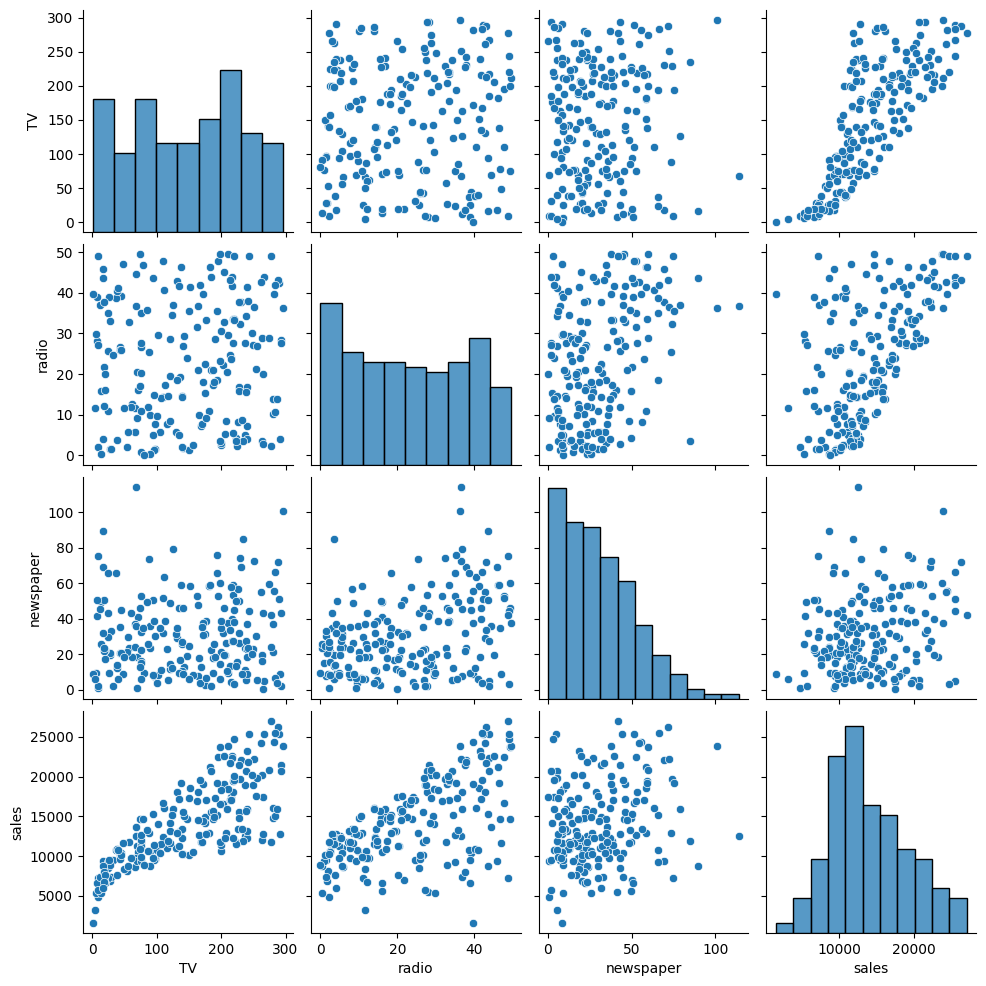

In [13]:
sns.pairplot(df)

<Axes: >

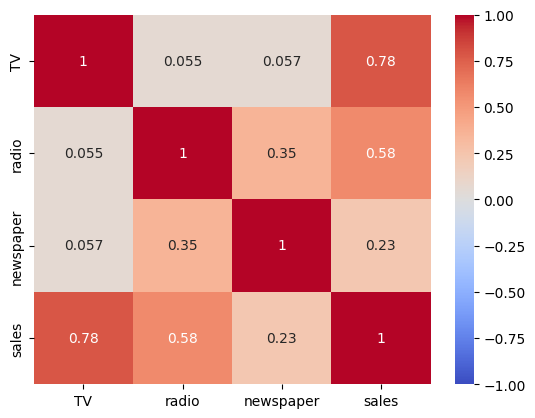

In [14]:
sns.heatmap(df.corr(), annot=True, vmin=-1, cmap="coolwarm")

## Modelado

In [ ]:
# Manipulación datasets, entrenamiento, evaluación, nuevas iteraciones... Prueba modelos sin y con regularización.

In [ ]:
# Utiliza todas las celdas que necesites...

In [19]:
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


In [22]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [23]:
y_pred = lr.predict(X_test)

print("R2 score", lr.score(X_test, y_test))
print("MAE", mean_absolute_error(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))
print("RMSE", mean_squared_error(y_test, y_pred)**(1/2))

R2 score 0.899438024100912
MAE 1460.7567168117605
MSE 3174097.3539761053
RMSE 1781.5996615334504


In [31]:
def train_eval_model(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("R2 score", model.score(X_test, y_test))
    print("MAE", mean_absolute_error(y_test, y_pred))
    print("MSE", mean_squared_error(y_test, y_pred))
    print("RMSE", mean_squared_error(y_test, y_pred)**(1/2))
    sns.displot(y_pred - y_test)
    return model

R2 score 0.899438024100912
MAE 1460.7567168117605
MSE 3174097.3539761053
RMSE 1781.5996615334504


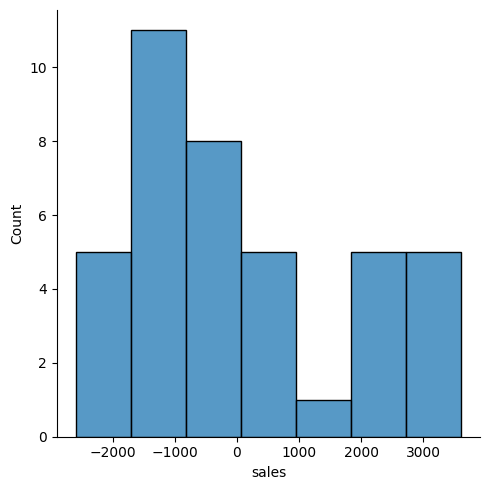

In [32]:
model_1 = train_eval_model(X_train, X_test, y_train, y_test, lr)

In [34]:
scaler = StandardScaler()
X_train_scal = scaler.fit_transform(X_train)
X_test_scal = scaler.transform(X_test)

R2 score 0.8994380241009119
MAE 1460.7567168117607
MSE 3174097.353976108
RMSE 1781.5996615334514


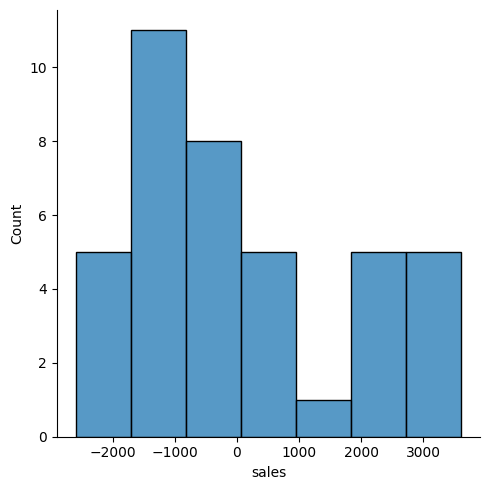

In [35]:
model_2 = train_eval_model(X_train_scal, X_test_scal, y_train, y_test, lr)

In [37]:
print(X_train_scal.mean())
print(X_train_scal.std())

-1.5635640930137622e-16
1.0


In [38]:
scaler = MinMaxScaler()
X_train_scal = scaler.fit_transform(X_train)
X_test_scal = scaler.transform(X_test)

In [39]:
print(X_train_scal.min())
print(X_train_scal.max())

0.0
1.0


R2 score 0.9005833101920356
MAE 1444.3023138227582
MSE 3137948.009068354
RMSE 1771.4254173033519


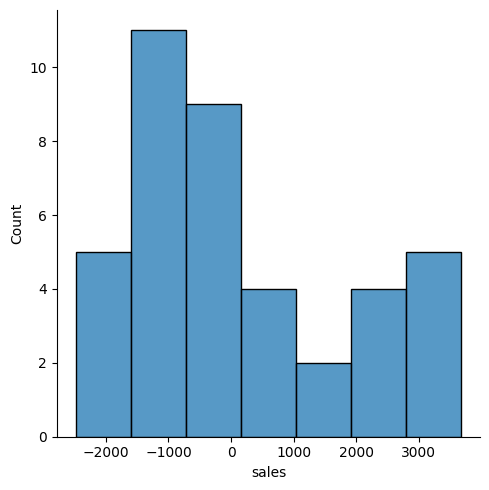

In [43]:
X = df[['TV', 'radio']]
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_3 = train_eval_model(X_train, X_test, y_train, y_test, lr)

#### Debemos de aumentar o reducir la la complejidad de nuestros modelos?

R2 score 0.9012861646445152
MAE 1443.7021156010182
MSE 3115763.3966649086
RMSE 1765.1525137123162


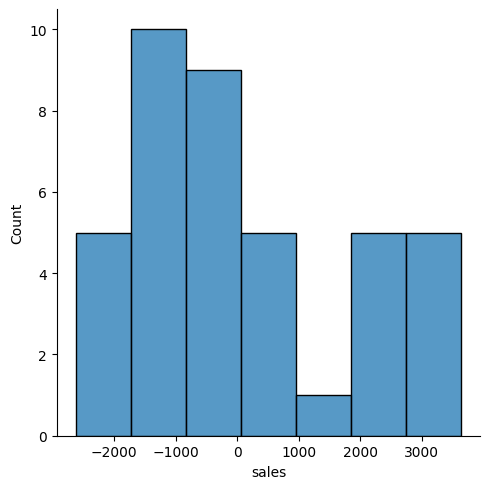

In [52]:
model_4 = train_eval_model(X_train, X_test, y_train, y_test, Ridge(alpha=1000))

R2 score 0.9884627879931582
MAE 493.4820298266892
MSE 364155.872791575
RMSE 603.4532896517965


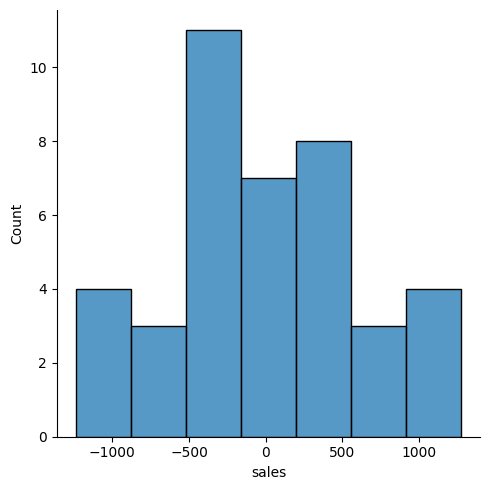

In [54]:
pol_2 = PolynomialFeatures(degree=2)

X_train_pol2 = pol_2.fit_transform(X_train)
X_test_pol2 = pol_2.transform(X_test)

model_5 = train_eval_model(X_train_pol2, X_test_pol2, y_train, y_test, LinearRegression())

R2 score 0.9943380835619904
MAE 335.8526633159307
MSE 178710.4302957809
RMSE 422.7415644288848


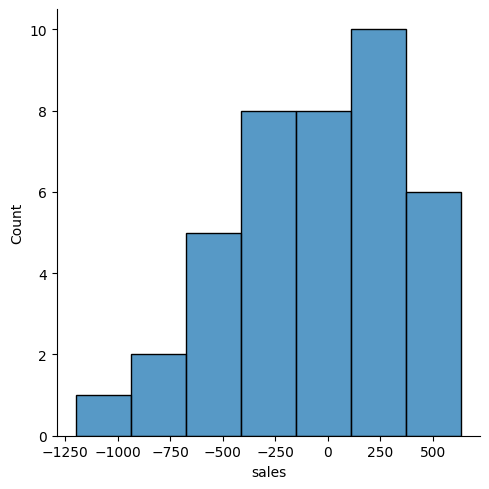

In [55]:
pol_3 = PolynomialFeatures(degree=3)

X_train_pol3 = pol_3.fit_transform(X_train)
X_test_pol3 = pol_3.transform(X_test)

model_6 = train_eval_model(X_train_pol3, X_test_pol3, y_train, y_test, LinearRegression())

R2 score 0.9939190345581926
MAE 356.9823087148947
MSE 191937.12281299755
RMSE 438.1062916838761


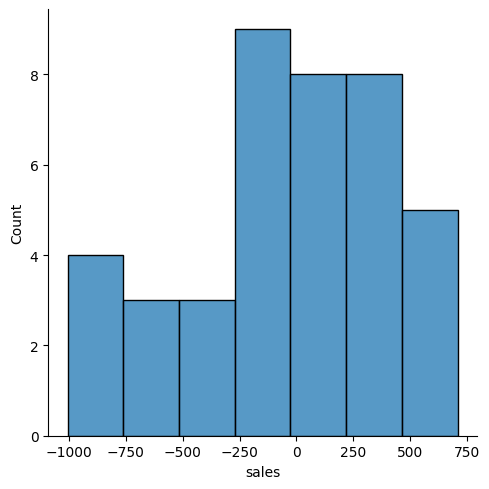

In [56]:
pol_4 = PolynomialFeatures(degree=4)

X_train_pol4 = pol_4.fit_transform(X_train)
X_test_pol4 = pol_4.transform(X_test)

model_6 = train_eval_model(X_train_pol4, X_test_pol4, y_train, y_test, LinearRegression())

R2 score 0.9933022836004176
MAE 357.80975686090017
MSE 211403.99948913194
RMSE 459.7869066090638


c:\Users\Miguel Angel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.328e+07, tolerance: 4.150e+05
  model = cd_fast.enet_coordinate_descent(


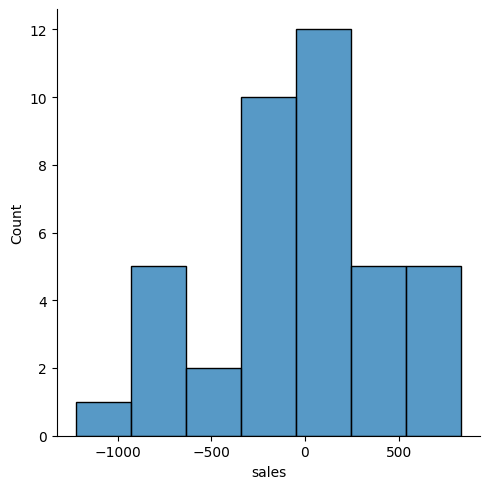

In [72]:
pol_3 = PolynomialFeatures(degree=4)

X_train_pol3 = pol_3.fit_transform(X_train)
X_test_pol3 = pol_3.transform(X_test)

model_6 = train_eval_model(X_train_pol3, X_test_pol3, y_train, y_test, Lasso(alpha=100))

c:\Users\Miguel Angel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.242e+07, tolerance: 4.150e+05
  model = cd_fast.enet_coordinate_descent(


R2 score 0.9943113155305515
MAE 328.81363641729496
MSE 179555.32556560493
RMSE 423.7396908074637


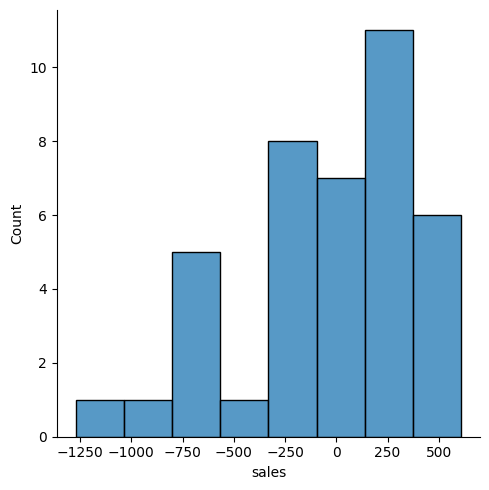

In [81]:
pol_3 = PolynomialFeatures(degree=3)

X_train_pol3 = pol_3.fit_transform(X_train)
X_test_pol3 = pol_3.transform(X_test)

model_7 = train_eval_model(X_train_pol3, X_test_pol3, y_train, y_test, Lasso(alpha=100))

## Resultados

In [ ]:
# Interpreta, resume y destaca los puntos importantes de los resultados.

In [ ]:
# Utiliza todas las celdas que necesites...

In [82]:
model_7

Lasso(alpha=100)

In [83]:
new_campaign = [[80,20], [50,50],[110,10]]

In [84]:
model_7.predict(pol_3.transform(new_campaign))

c:\Users\Miguel Angel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([11224.73414083, 12286.33043817, 11118.66496031])

In [85]:
model_7.intercept_

4805.1498915118555

In [86]:
model_7.coef_

array([ 0.00000000e+00,  7.54036535e+01,  0.00000000e+00, -3.57607897e-01,
        1.47552660e+00,  5.28682364e-01,  6.21248607e-04, -1.09058873e-03,
       -2.19247279e-03, -5.82225545e-04])

In [87]:
pol_3.get_feature_names_out()

array(['1', 'TV', 'radio', 'TV^2', 'TV radio', 'radio^2', 'TV^3',
       'TV^2 radio', 'TV radio^2', 'radio^3'], dtype=object)